In [91]:
import sys
import pickle
sys.path.append("../")

from models.bulge_models import BulgeTemplates
from models.templates import LorimerDiskTemplate
from models.np_model import NPModel

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist

In [115]:
import healpy as hp
import matplotlib.pyplot as plt
import arviz as az

In [116]:
r_outer = 25
l_max = 2

vary_disk = True
vary_gamma = True
bulge_hybrid = True

ps_cat = "3fgl"
nside = 128

npmodel = NPModel(r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=7500, guide="iaf_mixture", lr=3e-4)

Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|██████████| 7500/7500 [07:48<00:00, 16.01it/s, init loss: 35032.5825, avg. loss [7126-7500]: 20102.5271]


In [117]:
posterior = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=50000)

In [118]:
posterior_bulge = {}
for key in list(posterior.keys()):
    if "theta" in key:
        posterior_bulge[key] = posterior[key]
        posterior.pop(key, None)

In [119]:
az.summary(posterior)

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Alm_0,-0.028,0.023,-0.050,0.017,0.000,0.000,49606.0,50008.0,NaN
Alm_1,0.006,0.032,-0.043,0.050,0.000,0.000,49920.0,49545.0,NaN
Alm_2,-0.034,0.016,-0.050,-0.002,0.000,0.000,48636.0,49715.0,NaN
Alm_3,-0.006,0.029,-0.047,0.040,0.000,0.000,50179.0,49961.0,NaN
Alm_4,0.036,0.014,0.008,0.050,0.000,0.000,50345.0,50339.0,NaN
Alm_5,-0.015,0.027,-0.048,0.032,0.000,0.000,47918.0,49382.0,NaN
C,3.283,0.684,2.153,4.490,0.003,0.002,49583.0,48518.0,NaN
S_bub,1.159,0.061,1.046,1.273,0.000,0.000,50638.0,49574.0,NaN
S_dif,11.386,0.104,11.201,11.568,0.000,0.000,49616.0,49221.0,NaN
S_gce,0.967,0.276,0.489,1.463,0.001,0.001,49759.0,49501.0,NaN


In [120]:
jnp.mean(posterior_bulge['theta_bulge_poiss'], 0)

DeviceArray([0.1177679 , 0.18547707, 0.08702242, 0.3282973 , 0.28143531],            dtype=float64)

In [121]:
jnp.mean(posterior_bulge['theta_bulge_ps'], 0)

DeviceArray([0.06287029, 0.1532153 , 0.17514554, 0.29390892, 0.31485995],            dtype=float64)

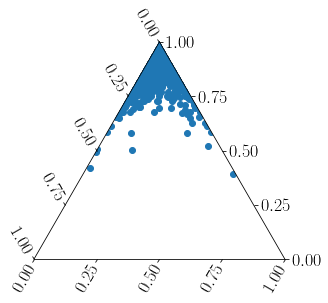

In [122]:
import mpltern

ax = plt.subplot(projection='ternary')
ax.scatter(*posterior_bulge['theta_ics'].T)     

In [123]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_ics'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.973,0.040,0.898,1.000,0.0,0.0,50301.0,49571.0,NaN
1,0.016,0.031,0.000,0.074,0.0,0.0,50378.0,49707.0,NaN
2,0.011,0.026,0.000,0.054,0.0,0.0,50288.0,49293.0,NaN


In [124]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_pibrem'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.813,0.070,0.684,0.927,0.0,0.0,50538.0,50212.0,NaN
1,0.148,0.071,0.028,0.281,0.0,0.0,50062.0,49908.0,NaN
2,0.038,0.048,0.000,0.132,0.0,0.0,50342.0,49388.0,NaN


## Config scan

In [ ]:
import numpy as np

ps_cat = "3fgl"
r_outer = 25

for nside in [128]:
    # for config in ["000","100","110","111"]:
    #     for l_max in [0, 3]:
    for config in ["111"]:
        for l_max in [3]:
        
            vary_disk = int(config[0])
            vary_gamma = int(config[1])
            bulge_hybrid = int(config[2])
            
            npmodel = NPModel(r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
            svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(42), n_steps=5000, guide="iaf", lr=1e-4)
            
            posterior = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(4232), num_samples=50000)
            posterior['logZ'] = np.array(jnp.mean(svi_results.losses[-250:]))  # Save log-evidence estimate
            
            posterior_file = "../data/posteriors/posterior_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}_ps_{}_nside_{}.p".format(r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma, ps_cat, nside)
            
            # Save data (serialize)
            with open(posterior_file, 'wb') as outfile:
                pickle.dump(posterior, outfile, protocol=pickle.HIGHEST_PROTOCOL)

            # Load data (deserialize)
            with open(posterior_file, 'rb') as handle:
                posterior = pickle.load(handle)